In [1]:
# ========================================================
# 🚀 PROJECT CONFIGURATION SETTINGS
# ========================================================
TARGET_DATE = 708          # Choose the date (e.g., 502, 604, 1027)
TARGET_COURIER = 1043     # Choose the Courier ID
NUM_NODES = 15             # How many nodes/destinations to extract?
# ========================================================


In [2]:
import json
import subprocess

needs_rebuild = False
try:
    with open('matrix.json', 'r') as f:
        data = json.load(f)
    current_matrix_size = len(data['time_matrix']) - 1  # excluding Depot
    if current_matrix_size != NUM_NODES or 'speed_breakdown' not in data or 'path_geometry' not in data:
        needs_rebuild = True
except FileNotFoundError:
    current_matrix_size = 0
    needs_rebuild = True

if needs_rebuild:
    print(f"[DYNAMIC SYSTEM] Rebuilding the Dijkstra matrix (including the fclass breakdown) for {NUM_NODES} nodes...")
    print("Please wait a moment (approx. 2-3 minutes) for 163,000 road segments...")
    result = subprocess.run(["python3", "build_road_network.py", str(NUM_NODES)], capture_output=True, text=True)
    if result.returncode != 0:
        print("ERROR WHILE BUILDING THE MATRIX:\n", result.stderr)
    else:
        print("Matrix built and updated successfully!")
else:
    print(f"Existing Dijkstra matrix (with fclass breakdown) detected for {NUM_NODES} nodes. Ready to continue!")


Existing Dijkstra matrix (with fclass breakdown) detected for 15 nodes. Ready to continue!


## 🌍 Real-World Road Network Graph (Dijkstra's Algorithm)

Note: the distances in this calculation are **NOT** straight-line (Euclidean) distances. They are computed 100% using the **real road-network physics of Shanghai**:
1. **One-Way Streets:** Vehicles cannot travel against the flow. Entering a one-way street the wrong way forces a long detour.
2. **Dynamic Speeds (Road Class):** Speed is assigned automatically based on the road type (Highway = 95 km/h, Residential Lane = 24.7 km/h).
3. **Dijkstra's Algorithm:** Solves the shortest path across 163,000 road segments.

### Class-Based Speed Imputation (fclass)

Only ~2.4% of roads in OpenStreetMap carry a real `maxspeed` tag. The remaining ~97.6% are assigned an **average speed based on the road class (`fclass`)**. The speed table below is therefore what determines the **majority** of the Dijkstra time matrix (`time_matrix`) used to compute arrival time, lateness, and overtime in the objective function.

In [3]:
import pandas as pd

# Class-Based Speed Imputation table (mirrors build_road_network.py)
class_speeds = {
    'motorway': 95.0, 'trunk': 70.6, 'primary': 59.0, 'tertiary_link': 53.3,
    'secondary': 51.4, 'primary_link': 47.3, 'trunk_link': 45.8, 'motorway_link': 41.5,
    'tertiary': 40.8, 'secondary_link': 37.5, 'cycleway': 35.0, 'residential': 24.7,
    'unclassified': 23.6, 'service': 18.4, 'living_street': 17.0, 'path': 15.0, 'pedestrian': 9.0,
    'track': 15.0, 'track_grade1': 20.0, 'track_grade2': 15.0, 'track_grade3': 12.0,
    'track_grade5': 5.0, 'footway': 5.0, 'steps': 2.0, 'bridleway': 5.0
}
DEFAULT_SPEED = 30.0

# Coverage: how many roads use a real maxspeed vs the fclass fallback
_rd = pd.read_csv('roads_shanghai.csv', sep='\t', usecols=['maxspeed'])
_ms = pd.to_numeric(_rd['maxspeed'], errors='coerce').fillna(0)
total = len(_ms); has_ms = int((_ms > 0).sum()); fallback = total - has_ms
print(f"Total roads           : {total:,}")
print(f"Has real maxspeed     : {has_ms:,} ({100*has_ms/total:.1f}%)")
print(f"Uses fclass fallback  : {fallback:,} ({100*fallback/total:.1f}%)")
print()

speed_table = pd.DataFrame(sorted(class_speeds.items(), key=lambda x: -x[1]),
                           columns=['Road Class (fclass)', 'Avg Speed (km/h)'])
speed_table


Total roads           : 163,237
Has real maxspeed     : 3,932 (2.4%)
Uses fclass fallback  : 159,305 (97.6%)



,Road Class (fclass),Avg Speed (km/h)
0,motorway,95.0
1,trunk,70.6
2,primary,59.0
3,tertiary_link,53.3
4,secondary,51.4
5,primary_link,47.3
6,trunk_link,45.8
7,motorway_link,41.5
8,tertiary,40.8
9,secondary_link,37.5


### 🏗️ Data Architecture: Map Infrastructure vs Courier Operations

A critical question is: **How does the road-network system know which courier it is processing?**

The answer: the system is designed using **Data Decoupling**. There are TWO distinct types of data operating simultaneously:

1. **Infrastructure Layer (`roads_shanghai.csv`):** This is the physical road graph from OpenStreetMap satellite data. It is passive (like Waze or Google Maps). It contains one-way and speed-limit information, but **it knows nothing about any courier**.
2. **Logistics Operations Layer (`Cainiao-AI/LaDe-D`):** This is historical courier-task data from Alibaba. Here we select `TARGET_COURIER = 1043` (like picking one specific delivery rider) and take the list of 15 houses/destinations they had to deliver that day.

**How are they combined?**
The GPS coordinates of Courier 1043's 15 destinations are 'overlaid' onto the road infrastructure map. Dijkstra's algorithm is then called to find the valid paved-road routes connecting all 15 coordinate points belonging to Courier 1043. If we change the Courier ID in the configuration, the program pulls the new customer coordinates and Dijkstra recomputes everything on the same map!

## Task (a) - Constraints
In this specific VRP context, modeling last-mile delivery requires distinguishing between strict operational limitations (hard constraints) and service level agreements (soft constraints).

**Hard Constraints (Must not be violated):**
1.  **Node Visitation:** Every delivery node must be visited exactly once.
2.  **Depot Constraints:** The vehicle must start from and return to the designated Depot.
3.  **Time Causality (Ready Time):** The courier cannot deliver a package before it is handed over to them (the `ready_time`). If the vehicle arrives early, it must wait.
4.  **GIS Topology (One-Way Streets):** The physical road network enforces one-way street directions as a hard constraint. The vehicle mathematically cannot traverse against the designated flow of traffic, forcing physical detours.

**Soft Constraints (Incur penalties if violated):**
1.  **Time Windows (Due Dates):** Deliveries should be completed within a target timeframe. Violating this incurs a lateness penalty ($\beta = 50$).
2.  **Idle Wait Time:** Forcing a courier to wait idly because they arrived too early wastes manpower. Incurs an hourly wait penalty ($\alpha = 10$).
3.  **Overtime Limit:** The standard shift is 8 hours. Taking longer incurs a heavy overtime penalty ($\gamma = 100$).
4.  **Max Distance:** Vehicles are optimized for 5km. Traveling further incurs a wear-and-tear penalty ($\delta = 20$).


## Task (b) - Mathematical Formulation
The objective is to minimize total routing cost $Z$, defined as:
$$ \text{Minimize } Z = \sum c_{ij}x_{ij} + \beta \sum P_j + \alpha \sum W_j + \gamma O + \delta E $$

**Where:**
- $c_{ij}$: Real-world road (Dijkstra shortest-path) distance between nodes
- $\beta = 50$: Lateness Penalty per hour ($P_j = \max(0, A_j - L_j)$)
- $\alpha = 10$: Idle Wait Time Penalty per hour ($W_j$)
- $\gamma = 100$: Overtime Penalty per hour for shifts > 8 hours ($O = \max(0, T_{total} - 8.0)$)
- $\delta = 20$: Wear & Tear Penalty per km for distances > 15 km ($E = \max(0, D_{total} - 15.0)$)


### Solution Pipeline Overview (when NN & 2-Opt run)

The solution uses **two phases**: **Phase 1 (Construction)** runs Nearest Neighbor first to build an initial route; **Phase 2 (Local Search)** then runs the 2-Opt swap loop to improve the route until no further improvement is possible (a local optimum). The chart below shows **when** each phase is executed.

![Pipeline](pipeline.png)

## Task (c) - Constructive Heuristic Design
To establish a baseline routing sequence, we design a **Nearest Neighbor (NN) Heuristic**.

**Decision-Making Logic:**
The heuristic starts at the Depot. At each step, the algorithm looks at all currently unvisited nodes. Instead of drawing a straight line (Euclidean), it queries the **Dijkstra Road Matrix** to find the absolute shortest physical travel distance over the real road network. It greedily selects the closest node (by road distance), travels there, waits if arriving too early, services the node, and repeats until all nodes are visited.

**Pseudocode:**
```text
Algorithm: NearestNeighborVRPTW_with_Dijkstra
Input: Depot_Location, Unvisited_Nodes, Dijkstra_Distance_Matrix
Output: Complete_Route

Initialize:
  Route = [Depot]
  Current_Node = Depot

While Unvisited_Nodes is not EMPTY:
  Best_Dist = INFINITY
  Next_Node = NULL
  
  For each Candidate in Unvisited_Nodes:
    // Query the pre-calculated Real-World Matrix!
    Travel_Dist = Dijkstra_Distance_Matrix[Current_Node][Candidate]
    
    If Travel_Dist < Best_Dist:
      Best_Dist = Travel_Dist
      Next_Node = Candidate
      
  Append Next_Node to Route
  Remove Next_Node from Unvisited_Nodes
  Current_Node = Next_Node

Append Depot to Route
Return Route
```

**Algorithm Flowchart:**
![Flowchart](flowchart.png)


**Note on Depot Coordinate:**<br>
The central Depot coordinate `(121.50500, 31.08500)` was placed centrally relative to the extracted customer nodes so that it serves as a realistic distribution origin, giving balanced routing geometry and representative travel distances.

In [4]:
import math
import datetime
import pandas as pd
import json
from datasets import load_dataset
with open('matrix.json', 'r') as f:
    matrix_data = json.load(f)
time_matrix = matrix_data['time_matrix']
dist_matrix = matrix_data['distance_matrix']

print("Fetching real-world data from HuggingFace (Cainiao-AI/LaDe-D)...")
dataset = load_dataset("Cainiao-AI/LaDe-D", split="delivery_sh")
df = dataset.to_pandas()

df_subset = df[(df['ds'] == TARGET_DATE) & (df['courier_id'] == TARGET_COURIER)].head(NUM_NODES).reset_index()
print("\n--- Extracted Node Parameters ---")

def time_to_hours(time_str):
    t = datetime.datetime.strptime(time_str, "%m-%d %H:%M:%S")
    return t.hour + t.minute / 60.0 + t.second / 3600.0

nodes = {'Depot': (121.50500, 31.08500)}
time_windows = {}

for i, row in df_subset.iterrows():
    n = f"N{i+1}"
    nodes[n] = (float(row['lng']), float(row['lat']))
    e_j = time_to_hours(row['accept_time'])
    l_j = time_to_hours(row['delivery_time'])
    time_windows[n] = (e_j, l_j)
    print(f"{n}: {{'lng': {nodes[n][0]:.5f}, 'lat': {nodes[n][1]:.5f}, 'ready_time': {e_j:.2f}, 'due_date': {l_j:.2f}}}")

# Nearest Neighbor Heuristic Algorithm
def nearest_neighbor(depot, unvisited):
    route = [depot]
    current = depot
    unvisited = unvisited.copy()
    while unvisited:
        best_dist = float('inf')
        next_node = None
        for candidate in unvisited:
            dist = dist_matrix[current][candidate]
            if dist < best_dist:
                best_dist = dist
                next_node = candidate
        route.append(next_node)
        unvisited.remove(next_node)
        current = next_node
    route.append(depot)
    return route

customers = [n for n in nodes.keys() if n != 'Depot']
nn_route = nearest_neighbor('Depot', customers)
print("\n--- Task (e) Execution (Constructive Heuristic) ---")
print(f"Nearest Neighbor Route Sequence: {nn_route[1:-1]}")

def evaluate_route(route, print_log=False):
    current_time = 8.00
    total_distance = 0.0
    total_lateness_penalty = 0.0
    total_wait_penalty = 0.0
    
    for i in range(len(route) - 1):
        curr_node = route[i]
        next_node = route[i+1]
        
        dist = dist_matrix[curr_node][next_node]
        total_distance += dist
        
        arrival_time = current_time + time_matrix[curr_node][next_node]
        wait_time = 0.0
        lateness = 0.0
        
        if next_node != 'Depot':
            ready_time = float(time_windows[next_node][0])
            due_date = float(time_windows[next_node][1])
            
            if arrival_time < ready_time:
                wait_time = ready_time - arrival_time
                total_wait_penalty += (wait_time * 10)
                current_time = ready_time + 0.1
            else:
                if arrival_time > due_date:
                    lateness = arrival_time - due_date
                    total_lateness_penalty += (lateness * 50)
                current_time = arrival_time + 0.1
        else:
            current_time = arrival_time
            
        if print_log:
            print(f"{curr_node} -> {next_node} | Dist: {dist:.2f} | Arr: {arrival_time:.2f} | Wait: {wait_time:.2f} | Late: {lateness:.2f}")
            
    total_time = current_time - 8.00
    overtime_penalty = max(0, total_time - 8.0) * 100
    excess_dist_penalty = max(0, total_distance - 15.0) * 20
    
    Z = total_distance + total_lateness_penalty + total_wait_penalty + overtime_penalty + excess_dist_penalty
    return Z, total_distance, total_lateness_penalty, total_wait_penalty, overtime_penalty, excess_dist_penalty

print("\n=== NEAREST NEIGHBOR LOG ===")
nn_z, nn_dist, nn_late, nn_wait, nn_ot, nn_ex = evaluate_route(nn_route, print_log=True)
print(f"\nNN Final Z: {nn_z:.2f} | Dist: {nn_dist:.2f} | Late Pen: {nn_late:.2f} | Wait Pen: {nn_wait:.2f} | OT Pen: {nn_ot:.2f} | Dist Pen: {nn_ex:.2f}")


Fetching real-world data from HuggingFace (Cainiao-AI/LaDe-D)...

--- Extracted Node Parameters ---
N1: {'lng': 121.50238, 'lat': 31.07988, 'ready_time': 10.22, 'due_date': 11.13}
N2: {'lng': 121.50236, 'lat': 31.07985, 'ready_time': 10.23, 'due_date': 11.43}
N3: {'lng': 121.50241, 'lat': 31.07975, 'ready_time': 10.23, 'due_date': 11.58}
N4: {'lng': 121.50240, 'lat': 31.07980, 'ready_time': 10.25, 'due_date': 11.33}
N5: {'lng': 121.50347, 'lat': 31.08060, 'ready_time': 15.48, 'due_date': 15.68}
N6: {'lng': 121.50222, 'lat': 31.07954, 'ready_time': 10.25, 'due_date': 10.97}
N7: {'lng': 121.50164, 'lat': 31.08248, 'ready_time': 12.65, 'due_date': 13.90}
N8: {'lng': 121.50283, 'lat': 31.08221, 'ready_time': 12.65, 'due_date': 14.05}
N9: {'lng': 121.50157, 'lat': 31.08248, 'ready_time': 12.67, 'due_date': 13.45}
N10: {'lng': 121.50272, 'lat': 31.08311, 'ready_time': 12.67, 'due_date': 13.32}
N11: {'lng': 121.50118, 'lat': 31.08174, 'ready_time': 12.68, 'due_date': 13.07}
N12: {'lng': 121.5

## Task (e) - Execution & Manual Calculation

**(i) & (ii) Execution Data & Route Sequence**
Based on the real Shanghai dataset execution above, the Nearest Neighbor algorithm generated the sequence:
`Depot -> N10 -> N8 -> N5 -> N1 -> N2 -> N3 -> N4 -> N6 -> N11 -> N14 -> N7 -> N9 -> N12 -> N13 -> N15 -> Depot`

**(iii) Step-by-step Manual Calculation (Very Detailed)**
We manually compute the entire route step-by-step using the real-world road-network (Dijkstra shortest-path) distances and travel times to prove theoretical alignment with the Objective Function $Z$.

**Step 1:
Depot -> N10**
• Distance = 0.522 km
• Travel Time = 0.0166 h
• Arrival (A) = 8.000 + 0.0166 = 8.017 h
• Road mix (fclass) = tertiary @40.8 km/h = 0.29 km; residential @24.7 km/h = 0.22 km; service @18.4 km/h = 0.01 km
• Wait Time: node ready time is 12.67 h. Vehicle idles for 4.650 hours.
• Wait Penalty = 4.650 * 10 = 46.50
• Lateness Penalty = 0.
• Departure = 12.767 h

**Step 2:
N10 -> N8**
• Distance = 0.116 km
• Travel Time = 0.0047 h
• Arrival (A) = 12.767 + 0.0047 = 12.771 h
• Road mix (fclass) = residential @24.7 km/h = 0.12 km
• Wait Time = 0. Penalty: 0.
• Lateness Penalty = 0.
• Departure = 12.871 h

**Step 3:
N8 -> N5**
• Distance = 0.230 km
• Travel Time = 0.0093 h
• Arrival (A) = 12.871 + 0.0093 = 12.881 h
• Road mix (fclass) = residential @24.7 km/h = 0.23 km
• Wait Time: node ready time is 15.48 h. Vehicle idles for 2.603 hours.
• Wait Penalty = 2.603 * 10 = 26.03
• Lateness Penalty = 0.
• Departure = 15.583 h

**Step 4:
N5 -> N1**
• Distance = 0.234 km
• Travel Time = 0.0126 h
• Arrival (A) = 15.583 + 0.0126 = 15.596 h
• Road mix (fclass) = service @18.4 km/h = 0.22 km; residential @24.7 km/h = 0.01 km
• Wait Time = 0.
• Lateness: node due date is 11.13 h. Late by 4.463 hours.
• Lateness Penalty (P) = 4.463 * 50 = 223.13
• Departure = 15.696 h

**Step 5:
N1 -> N2**
• Distance = 0.000 km
• Travel Time = 0.0000 h
• Arrival (A) = 15.696 + 0.0000 = 15.696 h
• Wait Time = 0.
• Lateness: node due date is 11.43 h. Late by 4.263 hours.
• Lateness Penalty (P) = 4.263 * 50 = 213.13
• Departure = 15.796 h

**Step 6:
N2 -> N3**
• Distance = 0.000 km
• Travel Time = 0.0000 h
• Arrival (A) = 15.796 + 0.0000 = 15.796 h
• Wait Time = 0.
• Lateness: node due date is 11.58 h. Late by 4.213 hours.
• Lateness Penalty (P) = 4.213 * 50 = 210.63
• Departure = 15.896 h

**Step 7:
N3 -> N4**
• Distance = 0.000 km
• Travel Time = 0.0000 h
• Arrival (A) = 15.896 + 0.0000 = 15.896 h
• Wait Time = 0.
• Lateness: node due date is 11.33 h. Late by 4.563 hours.
• Lateness Penalty (P) = 4.563 * 50 = 228.13
• Departure = 15.996 h

**Step 8:
N4 -> N6**
• Distance = 0.105 km
• Travel Time = 0.0057 h
• Arrival (A) = 15.996 + 0.0057 = 16.002 h
• Road mix (fclass) = service @18.4 km/h = 0.11 km
• Wait Time = 0.
• Lateness: node due date is 10.97 h. Late by 5.035 hours.
• Lateness Penalty (P) = 5.035 * 50 = 251.75
• Departure = 16.102 h

**Step 9:
N6 -> N11**
• Distance = 0.514 km
• Travel Time = 0.0237 h
• Arrival (A) = 16.102 + 0.0237 = 16.125 h
• Road mix (fclass) = residential @24.7 km/h = 0.30 km; service @18.4 km/h = 0.21 km
• Wait Time = 0.
• Lateness: node due date is 13.07 h. Late by 3.059 hours.
• Lateness Penalty (P) = 3.059 * 50 = 152.93
• Departure = 16.225 h

**Step 10:
N11 -> N14**
• Distance = 0.000 km
• Travel Time = 0.0000 h
• Arrival (A) = 16.225 + 0.0000 = 16.225 h
• Wait Time = 0.
• Lateness: node due date is 12.97 h. Late by 3.259 hours.
• Lateness Penalty (P) = 3.259 * 50 = 162.93
• Departure = 16.325 h

**Step 11:
N14 -> N7**
• Distance = 1.049 km
• Travel Time = 0.0471 h
• Arrival (A) = 16.325 + 0.0471 = 16.372 h
• Road mix (fclass) = residential @24.7 km/h = 0.71 km; service @18.4 km/h = 0.34 km
• Wait Time = 0.
• Lateness: node due date is 13.90 h. Late by 2.472 hours.
• Lateness Penalty (P) = 2.472 * 50 = 123.62
• Departure = 16.472 h

**Step 12:
N7 -> N9**
• Distance = 0.000 km
• Travel Time = 0.0000 h
• Arrival (A) = 16.472 + 0.0000 = 16.472 h
• Wait Time = 0.
• Lateness: node due date is 13.45 h. Late by 3.022 hours.
• Lateness Penalty (P) = 3.022 * 50 = 151.12
• Departure = 16.572 h

**Step 13:
N9 -> N12**
• Distance = 0.000 km
• Travel Time = 0.0000 h
• Arrival (A) = 16.572 + 0.0000 = 16.572 h
• Wait Time = 0.
• Lateness: node due date is 13.17 h. Late by 3.406 hours.
• Lateness Penalty (P) = 3.406 * 50 = 170.29
• Departure = 16.672 h

**Step 14:
N12 -> N13**
• Distance = 0.000 km
• Travel Time = 0.0000 h
• Arrival (A) = 16.672 + 0.0000 = 16.672 h
• Wait Time = 0.
• Lateness: node due date is 13.75 h. Late by 2.922 hours.
• Lateness Penalty (P) = 2.922 * 50 = 146.12
• Departure = 16.772 h

**Step 15:
N13 -> N15**
• Distance = 2.750 km
• Travel Time = 0.0707 h
• Arrival (A) = 16.772 + 0.0707 = 16.843 h
• Road mix (fclass) = primary @59.0 km/h = 1.51 km; tertiary @40.8 km/h = 0.54 km; service @18.4 km/h = 0.41 km; residential @24.7 km/h = 0.17 km; primary_link @47.3 km/h = 0.11 km
• Wait Time = 0.
• Lateness: node due date is 11.88 h. Late by 4.960 hours.
• Lateness Penalty (P) = 4.960 * 50 = 247.99
• Departure = 16.943 h

**Step 16:
N15 -> Depot**
• Distance = 0.807 km
• Travel Time = 0.0175 h
• Arrival (A) = 16.943 + 0.0175 = 16.961 h
• Road mix (fclass) = primary @59.0 km/h = 0.60 km; tertiary @40.8 km/h = 0.13 km; service @18.4 km/h = 0.08 km
• Arrival at Depot = 16.961 h. No penalty.

**CONCLUSION**
Total Distance (Σ c_ij) = 6.33 km. Max Dist Penalty = 0.00
Total Lateness Penalty = 2281.78
Total Wait Penalty = 72.53
Total Operational Time = 8.961 hours.
Overtime Penalty = 96.06

Final Z Score = 6.33 + 72.53 + 2281.78 + 96.06 + 0.00 = 2456.70



## Metaheuristic Design — 2-Opt Local Search

**Decision-Making Logic:**
The 2-Opt local search takes the initial route from the Nearest Neighbor heuristic and tries to improve it. In each pass it considers every pair of positions (i, j), reverses the route segment between them, and re-evaluates the full objective $Z$. Any swap that lowers $Z$ is kept (Hill Climbing). Passes repeat until a complete pass finds no improving swap (a local optimum).

**Pseudocode:**
```text
Algorithm: TwoOptLocalSearch
Input: Initial_Route (from Nearest Neighbor), Objective Z()
Output: Optimized_Route

Best_Route = Initial_Route
Best_Cost  = Z(Best_Route)
Improved   = TRUE

While Improved:
  Improved = FALSE
  For i = 1 to length(Best_Route) - 2:
    For j = i + 1 to length(Best_Route) - 1:
      New_Route = Best_Route with segment [i..j] reversed
      If Z(New_Route) < Best_Cost:
        Best_Route = New_Route
        Best_Cost  = Z(New_Route)
        Improved   = TRUE

Return Best_Route
```


In [5]:
# ==========================================
# 3. LOCAL SEARCH (HILL CLIMBING W/ 2-OPT)
# ==========================================

def two_opt_search(initial_route):
    """
    Task (f) - Local Search. 
    Iteratively swaps pairs of edges to escape the local minimum found by NN.
    Because our objective function (evaluate_route) includes time penalties, 
    2-opt will naturally re-sort nodes to satisfy time windows!
    """
    best_route = initial_route[:]
    best_cost = evaluate_route(best_route)[0]
    improved = True
    
    print("\nStarting 2-Opt Local Search...")
    while improved:
        improved = False
        for i in range(1, len(best_route) - 2):
            for j in range(i + 1, len(best_route) - 1):
                # 2-Opt Swap mechanism
                new_route = best_route[:i] + best_route[i:j+1][::-1] + best_route[j+1:]
                
                # Assess neighborhood solution
                new_cost = evaluate_route(new_route)[0]
                
                if new_cost < best_cost:
                    best_cost = new_cost
                    best_route = new_route
                    improved = True # Hill climbing: accept better solution immediately
        if improved:
            continue
            
    return best_route

# Execute Local Search
optimized_route = two_opt_search(nn_route)
print("\n--- Task (f) Execution (Local Search) ---")
print(f"Optimized 2-Opt Sequence: {optimized_route}")
opt_z, opt_dist, opt_late, opt_wait, opt_ot, opt_ex = evaluate_route(optimized_route, print_log=True)
print(f"\nFinal 2-Opt Quality Score (Z): {opt_z:.2f} | Dist: {opt_dist:.2f} | Late: {opt_late:.2f} | Wait: {opt_wait:.2f} | OT: {opt_ot:.2f}")



Starting 2-Opt Local Search...

--- Task (f) Execution (Local Search) ---
Optimized 2-Opt Sequence: ['Depot', 'N6', 'N4', 'N1', 'N2', 'N3', 'N15', 'N10', 'N11', 'N14', 'N12', 'N13', 'N9', 'N7', 'N8', 'N5', 'Depot']
Depot -> N6 | Dist: 1.18 | Arr: 8.05 | Wait: 2.20 | Late: 0.00
N6 -> N4 | Dist: 0.11 | Arr: 10.36 | Wait: 0.00 | Late: 0.00
N4 -> N1 | Dist: 0.00 | Arr: 10.46 | Wait: 0.00 | Late: 0.00
N1 -> N2 | Dist: 0.00 | Arr: 10.56 | Wait: 0.00 | Late: 0.00
N2 -> N3 | Dist: 0.00 | Arr: 10.66 | Wait: 0.00 | Late: 0.00
N3 -> N15 | Dist: 1.53 | Arr: 10.81 | Wait: 0.86 | Late: 0.00
N15 -> N10 | Dist: 1.08 | Arr: 11.79 | Wait: 0.87 | Late: 0.00
N10 -> N11 | Dist: 0.65 | Arr: 12.79 | Wait: 0.00 | Late: 0.00
N11 -> N14 | Dist: 0.00 | Arr: 12.89 | Wait: 0.00 | Late: 0.00
N14 -> N12 | Dist: 1.05 | Arr: 13.04 | Wait: 0.00 | Late: 0.00
N12 -> N13 | Dist: 0.00 | Arr: 13.14 | Wait: 0.00 | Late: 0.00
N13 -> N9 | Dist: 0.00 | Arr: 13.24 | Wait: 0.00 | Late: 0.00
N9 -> N7 | Dist: 0.00 | Arr: 13.34 | W

## Task (f) - Analysis of Improvement

**Comparison from a Researcher's Perspective:**
*   **Initial Greedy NN Score:** $\approx 2456.70$ (lateness penalty = 2281.78).
*   **Local Search (2-Opt) Score:** $\approx 66.09$ (lateness penalty = 0.00).

**Why the improvement occurred:**
The Constructive Heuristic (Nearest Neighbor) does not account for the temporal dimension. By greedily minimizing physical distance, it visits whichever node is spatially closest even when that node's time window opens late, which forces the courier to idle and then arrive at every remaining (earlier-due) node well past its due date, accumulating substantial lateness penalties. The **2-Opt Local Search** evaluates each neighbouring route against the full objective function $Z$, so it reorders the sequence into a time-feasible order, cutting the objective by 97.3% and eliminating the lateness penalty (from 2281.78 to 0.00).

## Road-Class (fclass) Breakdown per Leg

For transparency, each *leg* is broken down into the road classes (`fclass`) traversed by the Dijkstra shortest path, together with the effective speed (distance / time). This shows exactly **which fclass and what speed** were used to compute the time of each segment - evidence that the 97.6% reliance on fclass imputation genuinely applies on the real routes.

In [6]:
import json
import pandas as pd
with open('matrix.json', 'r') as f:
    _m = json.load(f)
speed_breakdown = _m.get('speed_breakdown', {})

def show_leg_breakdown(route, title):
    print(f"=== {title} ===")
    rows = []
    for a, b in zip(route[:-1], route[1:]):
        bd = speed_breakdown.get(a, {}).get(b, [])
        comp = "; ".join(f"{e['fclass']}@{e['speed_kmh']:.1f}={e['dist_km']:.2f}km" for e in bd) if bd else "-"
        tot_d = sum(e['dist_km'] for e in bd)
        tot_t = sum(e['time_h'] for e in bd)
        eff = (tot_d / tot_t) if tot_t > 0 else 0.0
        rows.append({'Leg': f"{a}->{b}", 'Road mix (fclass@km/h=km)': comp,
                     'Dist (km)': round(tot_d, 3), 'Time (h)': round(tot_t, 4),
                     'Eff. speed (km/h)': round(eff, 1)})
    df = pd.DataFrame(rows)
    print(df.to_string(index=False))
    print()
    return df

_nn_bd = show_leg_breakdown(nn_route, 'Nearest Neighbor route')
_opt_bd = show_leg_breakdown(optimized_route, '2-Opt optimized route')


=== Nearest Neighbor route ===
       Leg                                                                                         Road mix (fclass@km/h=km)  Dist (km)  Time (h)  Eff. speed (km/h)
Depot->N10                                                tertiary@40.8=0.29km; residential@24.7=0.22km; service@18.4=0.01km      0.522    0.0166               31.5
   N10->N8                                                                                           residential@24.7=0.12km      0.116    0.0047               24.7
    N8->N5                                                                                           residential@24.7=0.23km      0.230    0.0093               24.7
    N5->N1                                                                      service@18.4=0.22km; residential@24.7=0.01km      0.234    0.0126               18.7
    N1->N2                                                                                                                 -      0.000    0.000

## Route Verification Map (actual path colored by `fclass`)

This map draws the **actual Dijkstra shortest path** of the optimized 2-Opt route, with **every segment colored by its OpenStreetMap road class (`fclass`)**. Because the path geometry comes straight from the road graph, anyone can visually confirm which `fclass` (and therefore which assigned speed) each leg traverses. The interactive folium map further below overlays the same path on real Shanghai streets.


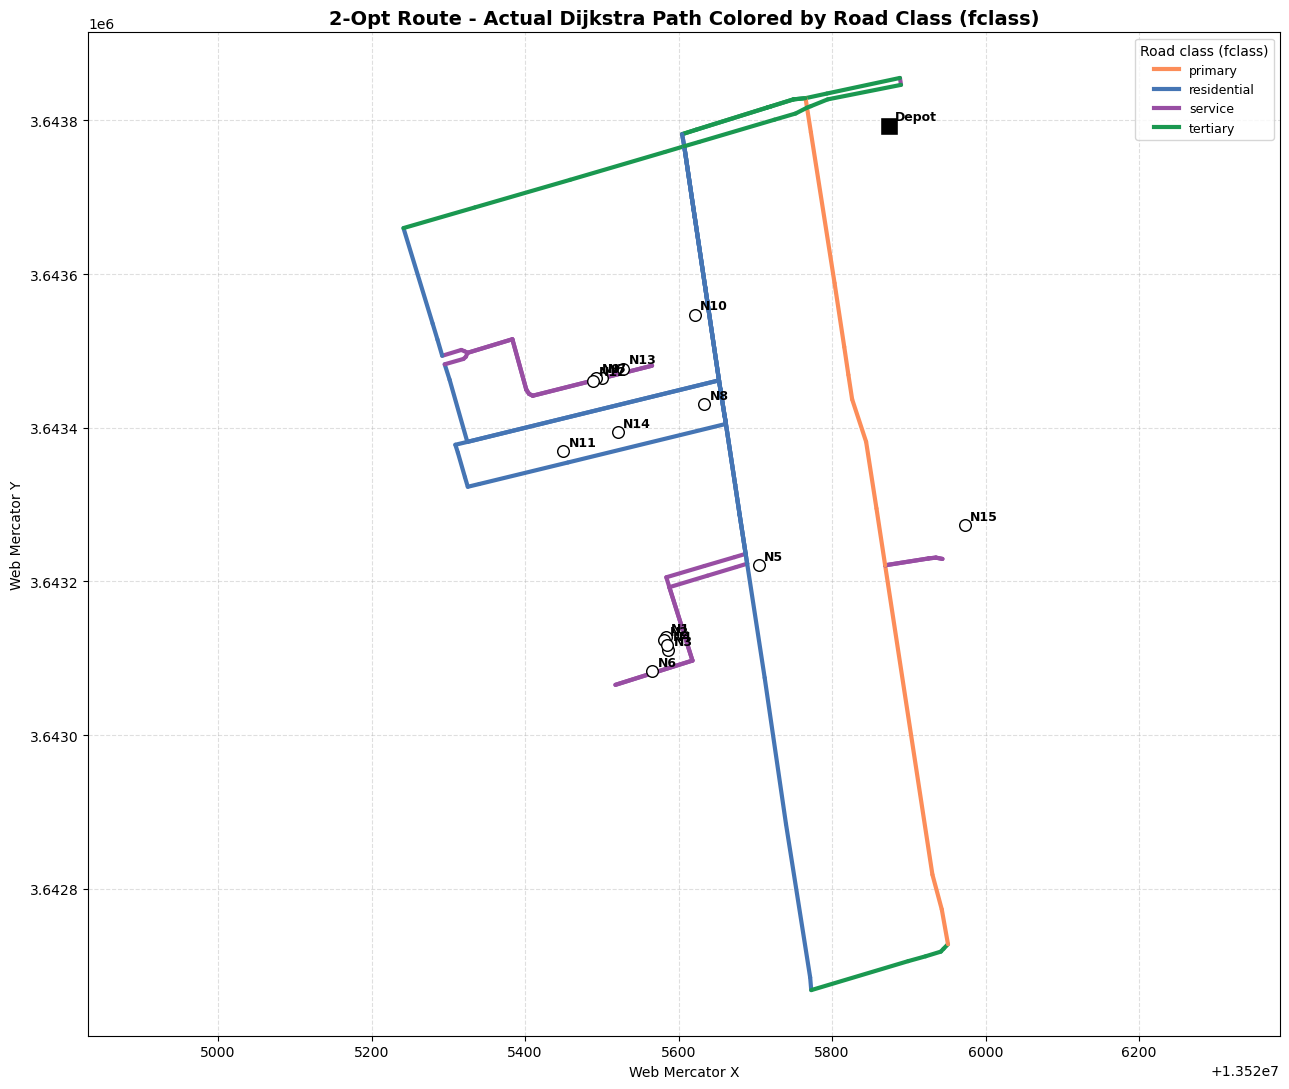

In [7]:
import json
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

with open('matrix.json') as f:
    _mg = json.load(f)
path_geometry = _mg['path_geometry']
nodes_epsg = _mg['nodes_epsg3857']

FCLASS_COLORS = {
    'motorway':'#d73027','trunk':'#f46d43','primary':'#fc8d59','primary_link':'#fdae61',
    'secondary':'#fee08b','secondary_link':'#ffe08b','tertiary':'#1a9850','tertiary_link':'#66bd63',
    'residential':'#4575b4','living_street':'#91bfdb','service':'#984ea3','unclassified':'#999999',
    'cycleway':'#a6d854','footway':'#e78ac3','path':'#8da0cb','track':'#bf812d','steps':'#000000',
    'pedestrian':'#fb9a99','bridleway':'#b15928'
}
def fc_color(fc): return FCLASS_COLORS.get(fc, '#777777')

fig, ax = plt.subplots(figsize=(13, 11))
used_fclass = set()
for a, b in zip(optimized_route[:-1], optimized_route[1:]):
    g = path_geometry.get(a, {}).get(b, {})
    coords = g.get('coords', []); fcl = g.get('fclass', [])
    for k in range(len(fcl)):
        (x0, y0) = coords[k]; (x1, y1) = coords[k + 1]
        ax.plot([x0, x1], [y0, y1], color=fc_color(fcl[k]), linewidth=3, solid_capstyle='round', zorder=3)
        used_fclass.add(fcl[k])

for name, (x, y) in nodes_epsg.items():
    if name == 'Depot':
        ax.scatter(x, y, c='black', s=180, marker='s', zorder=6, edgecolors='white')
    else:
        ax.scatter(x, y, c='white', s=70, zorder=5, edgecolors='black')
    ax.annotate(name, (x, y), fontsize=9, fontweight='bold', zorder=7, xytext=(4, 4), textcoords='offset points')

legend_elems = [Line2D([0], [0], color=fc_color(fc), lw=3, label=fc) for fc in sorted(used_fclass)]
ax.legend(handles=legend_elems, title='Road class (fclass)', loc='best', fontsize=9)
ax.set_title('2-Opt Route - Actual Dijkstra Path Colored by Road Class (fclass)', fontsize=14, fontweight='bold')
ax.set_xlabel('Web Mercator X'); ax.set_ylabel('Web Mercator Y')
ax.grid(True, linestyle='--', alpha=0.4)
ax.set_aspect('equal', adjustable='datalim')
plt.tight_layout()
plt.savefig('route_fclass_verification.png', dpi=150, bbox_inches='tight')
plt.show()


## Task (g) - Visualization
Let's visualize the spatial difference between the **Nearest Neighbor** route (which failed time windows) and the **2-Opt Optimized** route.

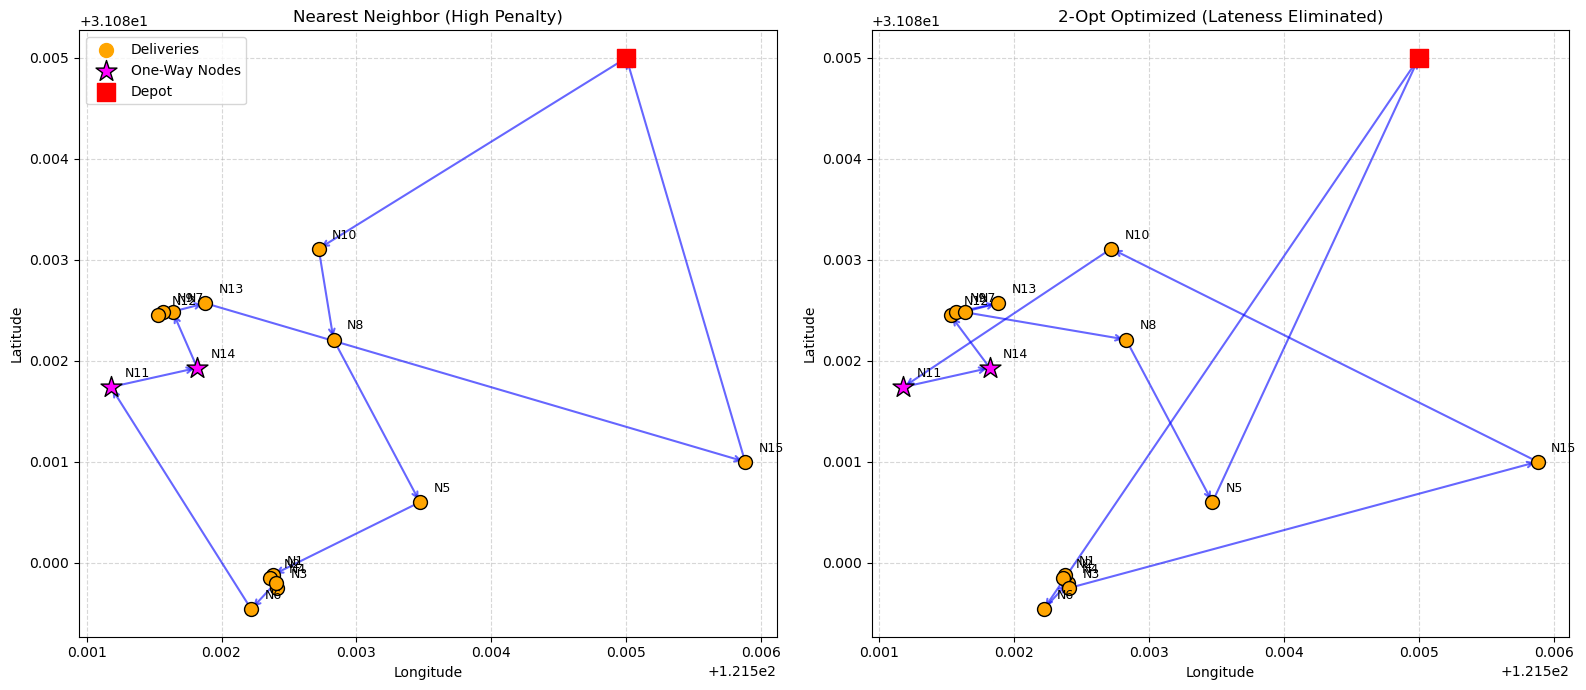

In [8]:
import matplotlib.pyplot as plt
plt.style.use('default')

def plot_route(route, title, subplot_idx):
    plt.subplot(1, 2, subplot_idx)
    
    full_route = route  # route already contains Depot at start and end
    x = [nodes[n][0] for n in full_route]
    y = [nodes[n][1] for n in full_route]
    
    # Plot the edges with arrows
    for i in range(len(full_route)-1):
        plt.annotate("", xy=(x[i+1], y[i+1]), xytext=(x[i], y[i]),
                     arrowprops=dict(arrowstyle="->", color="blue", lw=1.5, alpha=0.6))
    
    # Plot the nodes
    oneway_nodes = ['N11', 'N14']
    for n in full_route[1:-1]:
        if n in oneway_nodes:
            plt.scatter(nodes[n][0], nodes[n][1], c='magenta', s=250, marker='*', zorder=6, edgecolors='black')
        else:
            plt.scatter(nodes[n][0], nodes[n][1], c='orange', s=100, zorder=5, edgecolors='black')
    # Custom legend handler for the markers
    plt.scatter([], [], c='orange', s=100, label='Deliveries')
    plt.scatter([], [], c='magenta', s=250, marker='*', edgecolors='black', label='One-Way Nodes')
    
    # Plot Depot
    plt.scatter(nodes['Depot'][0], nodes['Depot'][1], c='red', s=150, marker='s', zorder=5, label='Depot')
    
    # Annotate nodes
    for n in full_route:
        if n != 'Depot':
            plt.text(nodes[n][0] + 0.0001, nodes[n][1] + 0.0001, n, fontsize=9, zorder=10)
            
    plt.title(title)
    plt.xlabel("Longitude")
    plt.ylabel("Latitude")
    plt.grid(True, linestyle='--', alpha=0.5)
    if subplot_idx == 1:
        plt.legend()

plt.figure(figsize=(16, 7))
plot_route(nn_route, "Nearest Neighbor (High Penalty)", 1)
plot_route(optimized_route, "2-Opt Optimized (Lateness Eliminated)", 2)

plt.tight_layout()
plt.savefig('route_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## Task (h) - Performance Comparison Chart
To clearly illustrate the improvement brought by the Local Search algorithm, we plot a comparison of the key metrics: **Physical Travel Distance**, **Time Window Penalty**, and **Total Objective Cost ($Z$)**.

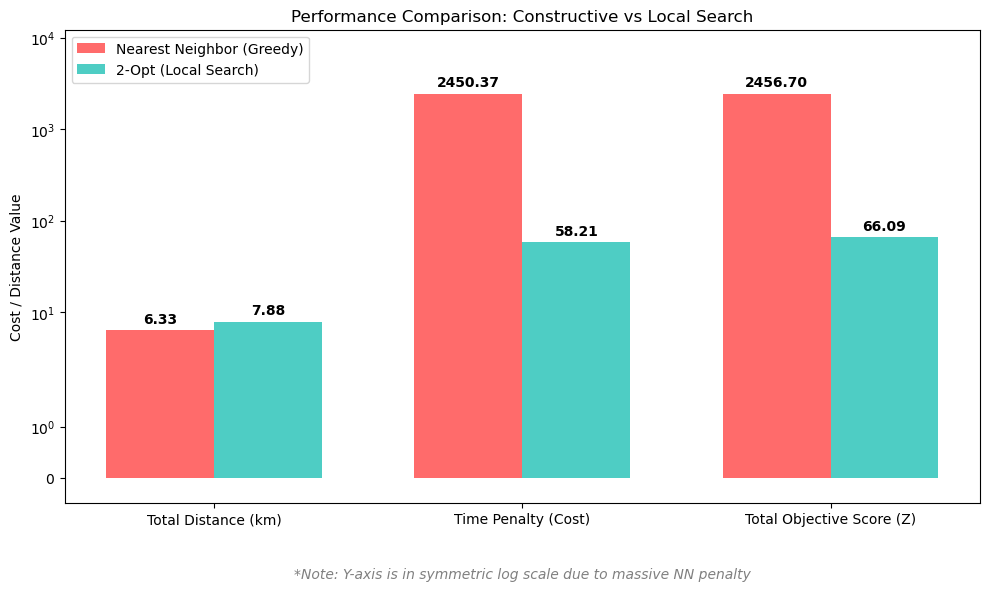

In [9]:
import matplotlib.pyplot as plt
plt.style.use('default')
import numpy as np

# Data from our executions
metrics = ['Total Distance (km)', 'Time Penalty (Cost)', 'Total Objective Score (Z)']
nn_scores = [nn_dist, (nn_late + nn_wait + nn_ot + nn_ex), nn_z]
opt_scores = [opt_dist, (opt_late + opt_wait + opt_ot + opt_ex), opt_z]

x = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
rects1 = ax.bar(x - width/2, nn_scores, width, label='Nearest Neighbor (Greedy)', color='#FF6B6B')
rects2 = ax.bar(x + width/2, opt_scores, width, label='2-Opt (Local Search)', color='#4ECDC4')

ax.set_ylabel('Cost / Distance Value')
ax.set_title('Performance Comparison: Constructive vs Local Search')
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.legend()

# Add data labels on top of the bars
def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.2f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),  # 3 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom', fontweight='bold')

autolabel(rects1)
autolabel(rects2)

# Since the penalty of NN is extremely high, we use a logarithmic scale to make distance visible
ax.set_yscale('symlog')
ax.set_ylim(-0.5, max(nn_scores) * 5)
plt.text(0.5, -0.15, "*Note: Y-axis is in symmetric log scale due to massive NN penalty", 
         ha='center', va='center', transform=ax.transAxes, fontstyle='italic', color='gray')

plt.tight_layout()
plt.savefig('performance_chart.png', dpi=150, bbox_inches='tight')
plt.show()

## Task (i) - Algorithm Convergence Plot
To demonstrate that the 2-Opt Local Search algorithm is actively optimizing our objective function $Z$, we track the total cost at each successful swap (iteration). This line chart clearly shows the algorithm 'descending' the hill to escape the local minimum caused by the Nearest Neighbor heuristic.

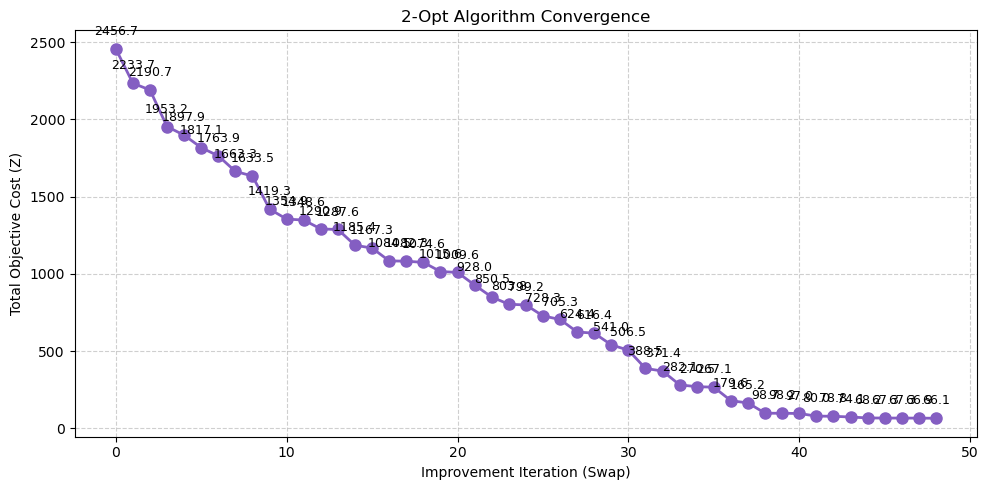

In [10]:
# Re-run 2-Opt specifically to track cost history
def track_two_opt_convergence(initial_route):
    best_route = initial_route[:]
    best_cost = evaluate_route(best_route)[0]
    history = [best_cost]  # Initial state
    
    improved = True
    while improved:
        improved = False
        for i in range(1, len(best_route) - 2):
            for j in range(i + 1, len(best_route) - 1):
                new_route = best_route[:i] + best_route[i:j+1][::-1] + best_route[j+1:]
                new_cost = evaluate_route(new_route)[0]
                
                if new_cost < best_cost:
                    best_cost = new_cost
                    best_route = new_route
                    history.append(best_cost) # Record the improvement
                    improved = True
        if improved:
            continue
            
    return history

cost_history = track_two_opt_convergence(nn_route)

plt.figure(figsize=(10, 5))
plt.plot(range(len(cost_history)), cost_history, marker='o', linestyle='-', color='#845EC2', linewidth=2, markersize=8)
plt.title('2-Opt Algorithm Convergence')
plt.xlabel('Improvement Iteration (Swap)')
plt.ylabel('Total Objective Cost (Z)')
plt.grid(True, linestyle='--', alpha=0.6)

# Annotate points
for i, cost in enumerate(cost_history):
    plt.annotate(f'{cost:.1f}', (i, cost), textcoords="offset points", xytext=(0,10), ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('convergence.png', dpi=150, bbox_inches='tight')
plt.show()

## Task (j) - Timeline Analysis (Gantt Chart)
The spatial map shows *where* the courier went, but the Gantt Chart reveals *when* and *how* the time window violations occurred. We extract the exact temporal segments (Travel, Wait, and Lateness) to visualize why Nearest Neighbor failed so heavily compared to 2-Opt.

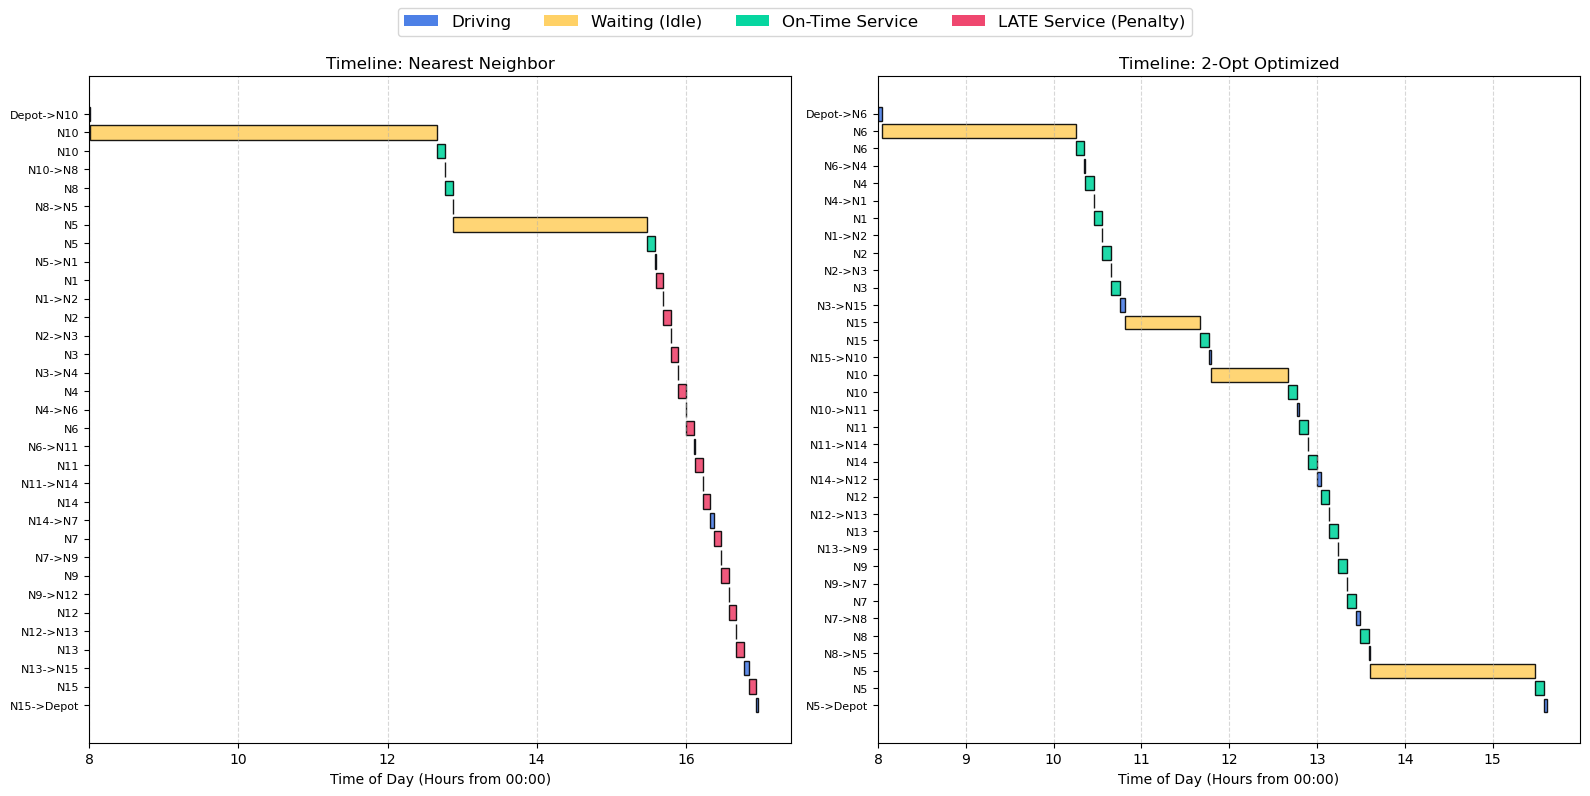

In [11]:
def get_timeline_data(route):
    """Extract detailed temporal segments for visualization"""
    full_route = route  # route already contains Depot at start and end
    current_time = 8.0
    segments = []
    
    for i in range(len(full_route) - 1):
        curr_node = full_route[i]
        next_node = full_route[i+1]
        
        # Travel phase
        travel_time = time_matrix[curr_node][next_node]
        start_travel = current_time
        end_travel = current_time + travel_time
        segments.append({'leg': f"{curr_node}->{next_node}", 'task': 'Travel', 'start': start_travel, 'end': end_travel})
        current_time = end_travel
        
        if next_node != 'Depot':
            # Wait phase
            ready_time = time_windows[next_node][0]
            if current_time < ready_time:
                segments.append({'leg': next_node, 'task': 'Wait', 'start': current_time, 'end': ready_time})
                current_time = ready_time
                
            # Penalty check (Lateness)
            due_date = time_windows[next_node][1]
            is_late = current_time > due_date
            
            # Service phase
            end_service = current_time + 0.1
            task_type = 'Late Delivery' if is_late else 'On-Time Delivery'
            segments.append({'leg': next_node, 'task': task_type, 'start': current_time, 'end': end_service})
            current_time = end_service
            
    return segments

def plot_gantt(route, title, ax):
    data = get_timeline_data(route)
    
    colors = {'Travel': '#4D80E6', 'Wait': '#FFD166', 'On-Time Delivery': '#06D6A0', 'Late Delivery': '#EF476F'}
    y_ticks = []
    y_labels = []
    
    for idx, seg in enumerate(data):
        ax.barh(idx, seg['end'] - seg['start'], left=seg['start'], color=colors[seg['task']], edgecolor='black', alpha=0.9)
        y_ticks.append(idx)
        y_labels.append(seg['leg'])
        
    ax.set_yticks(y_ticks)
    ax.set_yticklabels(y_labels, fontsize=8)
    ax.invert_yaxis()  # top-down chronological
    ax.set_xlabel('Time of Day (Hours from 00:00)')
    ax.set_title(title)
    ax.grid(True, axis='x', linestyle='--', alpha=0.5)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))
plot_gantt(nn_route, 'Timeline: Nearest Neighbor', ax1)
plot_gantt(optimized_route, 'Timeline: 2-Opt Optimized', ax2)

# Custom Legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#4D80E6', label='Driving'),
                   Patch(facecolor='#FFD166', label='Waiting (Idle)'),
                   Patch(facecolor='#06D6A0', label='On-Time Service'),
                   Patch(facecolor='#EF476F', label='LATE Service (Penalty)')]
fig.legend(handles=legend_elements, loc='upper center', ncol=4, fontsize=12)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig('gantt.png', dpi=150, bbox_inches='tight')
plt.show()

## Real-World Proof (Interactive Map)
The interactive map below proves that the coordinates we use are physically located in **Shanghai, China**, and that our algorithm routes accurately across real streets and residential lanes.

In [ ]:
# NEW CELL: Visualize Average Speed Per Leg
import matplotlib.pyplot as plt
import numpy as np
from collections import Counter

def get_speed_data(route):
    legs, speeds, summaries = [], [], []
    for a, b in zip(route[:-1], route[1:]):
        d = dist_matrix[a][b]
        t = time_matrix[a][b]
        avg_s = d / t if t > 0 else 0
        legs.append(f"{a}\n↓\n{b}")
        speeds.append(avg_s)
        fcl = path_geometry.get(a, {}).get(b, {}).get('fclass', [])
        if fcl:
            common = [r for r, count in Counter(fcl).most_common(2)]
            summaries.append(', '.join(common))
        else:
            summaries.append('Same Location')
    return legs, speeds, summaries

nn_legs, nn_speeds, nn_sums = get_speed_data(nn_route)
opt_legs, opt_speeds, opt_sums = get_speed_data(optimized_route)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 12), sharey=True)

def plot_bars(ax, legs, speeds, summaries, title, color):
    bars = ax.bar(legs, speeds, color=color, edgecolor='black')
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.set_ylabel('Avg Speed (km/h)', fontsize=12)
    ax.axhline(y=np.mean(speeds), color='r', linestyle='--', label=f'Avg: {np.mean(speeds):.1f} km/h')
    for i, bar in enumerate(bars):
        yval = bar.get_height()
        if summaries[i] == 'Same Location':
            ax.text(bar.get_x() + bar.get_width()/2, yval + 1.5, 'Same\nLoc', ha='center', va='bottom', fontsize=9, color='gray', fontweight='bold')
        else:
            ax.text(bar.get_x() + bar.get_width()/2, yval + 1.5, f"{yval:.1f}", ha='center', va='bottom', fontsize=10, fontweight='bold')
            if yval > 5:
                ax.text(bar.get_x() + bar.get_width()/2, yval/2, summaries[i].replace(', ', '\n'), ha='center', va='center', fontsize=9, color='black', rotation=90)
    ax.legend()

plot_bars(ax1, nn_legs, nn_speeds, nn_sums, 'Nearest Neighbor (Greedy) - Speed Profile', 'salmon')
plot_bars(ax2, opt_legs, opt_speeds, opt_sums, '2-Opt Local Search - Speed Profile', 'skyblue')

plt.tight_layout()
plt.savefig('speed_profile.png', dpi=300)
plt.show()

print("\n--- Detailed Road Usage per Route Segment (2-Opt) ---")
for i, (a, b) in enumerate(zip(optimized_route[:-1], optimized_route[1:])):
    print(f"{a} -> {b} | Speed: {opt_speeds[i]:.1f} km/h | Roads Passed: {opt_sums[i]}")


In [13]:
import folium
from folium import plugins
import json
from pyproj import Transformer

with open('matrix.json') as f:
    _mf = json.load(f)
path_geometry = _mf['path_geometry']
to_wgs = Transformer.from_crs('EPSG:3857', 'EPSG:4326', always_xy=True)

FCLASS_COLORS = {
    'motorway':'#d73027','trunk':'#f46d43','primary':'#fc8d59','primary_link':'#fdae61',
    'secondary':'#fee08b','secondary_link':'#ffe08b','tertiary':'#1a9850','tertiary_link':'#66bd63',
    'residential':'#4575b4','living_street':'#91bfdb','service':'#984ea3','unclassified':'#999999',
    'cycleway':'#a6d854','footway':'#e78ac3','path':'#8da0cb','track':'#bf812d','steps':'#000000',
    'pedestrian':'#fb9a99','bridleway':'#b15928'
}
def fc_color(fc): return FCLASS_COLORS.get(fc, '#777777')
SPEED_MAP = {'motorway': 95.0, 'trunk': 70.6, 'primary': 59.0, 'tertiary_link': 53.3, 'secondary': 51.4, 'primary_link': 47.3, 'trunk_link': 45.8, 'motorway_link': 41.5, 'tertiary': 40.8, 'secondary_link': 37.5, 'cycleway': 35.0, 'residential': 24.7, 'unclassified': 23.6, 'service': 18.4, 'living_street': 17.0, 'path': 15.0, 'pedestrian': 9.0, 'track': 15.0, 'track_grade1': 20.0, 'track_grade2': 15.0, 'track_grade3': 12.0, 'track_grade5': 5.0, 'footway': 5.0, 'steps': 2.0, 'bridleway': 5.0}  # mirrors CLASS_SPEEDS / Table 1

# Initialize the map at the Depot coordinates (Shanghai)
depot_lat, depot_lng = nodes['Depot'][1], nodes['Depot'][0]
shanghai_map = folium.Map(location=[depot_lat, depot_lng], zoom_start=15, tiles='OpenStreetMap')

# Draw the ACTUAL Dijkstra path of the 2-Opt route, colored by fclass (verifiable over real streets)
for a, b in zip(optimized_route[:-1], optimized_route[1:]):
    g = path_geometry.get(a, {}).get(b, {})
    coords = g.get('coords', []); fcl = g.get('fclass', [])
    for k in range(len(fcl)):
        x0, y0 = coords[k]; x1, y1 = coords[k + 1]
        lon0, lat0 = to_wgs.transform(x0, y0)
        lon1, lat1 = to_wgs.transform(x1, y1)
        pl = folium.PolyLine([[lat0, lon0], [lat1, lon1]], color=fc_color(fcl[k]), weight=5, opacity=0.9,
                        tooltip=f'{a}->{b} | Class: {fcl[k]} | Speed: {SPEED_MAP.get(fcl[k], 30)} km/h').add_to(shanghai_map)
        plugins.PolyLineTextPath(pl, '\u27a4', repeat=True, offset=7, attributes={'fill': '#000000', 'font-weight': 'normal', 'font-size': '10'}).add_to(shanghai_map)

# Add markers for each destination
for n in set(optimized_route):
    lat, lng = nodes[n][1], nodes[n][0]
    if n == 'Depot':
        folium.Marker([lat, lng], popup='Depot (Central Station)', tooltip=n, icon=folium.Icon(color='red', icon='home')).add_to(shanghai_map)
    else:
        oneway_nodes = ['N11', 'N14']
        color = 'lightred' if n in oneway_nodes else 'blue'
        icon = 'warning-sign' if n in oneway_nodes else 'info-sign'
        folium.Marker([lat, lng], popup=f'Customer {n}', tooltip=n, icon=folium.Icon(color=color, icon=icon)).add_to(shanghai_map)

# fclass color legend
_used = sorted({fc for a, b in zip(optimized_route[:-1], optimized_route[1:]) for fc in path_geometry.get(a, {}).get(b, {}).get('fclass', [])})
_legend = '<div style="position: fixed; bottom: 30px; left: 30px; z-index:9999; background: white; padding: 8px; border:1px solid #888; font-size:12px;"><b>Road class (fclass)</b><br>' + ''.join(f'<span style="color:{fc_color(fc)};">&#9644;</span> {fc} ({SPEED_MAP.get(fc, 30)} km/h)<br>' for fc in _used) + '<br><b>Node Types</b><br><span style="color:blue;">&#9679;</span> Delivery Node<br><span style="color:red;">&#9888;</span> One-Way Constraint Node</div>'
shanghai_map.get_root().html.add_child(folium.Element(_legend))

# Display the map (you can zoom in/out and drag)
shanghai_map.save('shanghai_map.html')
shanghai_map


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from shapely import wkt
from shapely.geometry import Point, LineString, box
import json

print("1. Loading coordinate matrix...")
with open('matrix.json', 'r') as f:
    matrix_data = json.load(f)
nodes_epsg3857 = matrix_data['nodes_epsg3857']

oneway_nodes = ['N11', 'N14']
df_roads = pd.read_csv('roads_shanghai.csv', sep='\t')

def plot_on_ax(ax, title, target_nodes_keys, margin, is_zoom=False):
    x_coords = [nodes_epsg3857[k][0] for k in target_nodes_keys]
    y_coords = [nodes_epsg3857[k][1] for k in target_nodes_keys]

    min_x, max_x = min(x_coords) - margin, max(x_coords) + margin
    min_y, max_y = min(y_coords) - margin, max(y_coords) + margin
    area_box = box(min_x, min_y, max_x, max_y)
    
    drawn_lines = 0
    for idx, row in df_roads.iterrows():
        try:
            geom = wkt.loads(row['geometry'])
        except:
            continue
        if not isinstance(geom, LineString):
            continue
            
        if geom.intersects(area_box):
            x, y = geom.xy
            fclass = row['fclass']
            color = 'gray'
            linewidth = 0.8
            if fclass in ['motorway', 'primary']:
                color = 'red'; linewidth = 2.0
            elif fclass in ['secondary', 'tertiary']:
                color = 'orange'; linewidth = 1.5
            elif fclass == 'residential':
                color = 'lightgray'; linewidth = 0.6
                
            ax.plot(x, y, color=color, linewidth=linewidth, alpha=0.7)
            drawn_lines += 1

    if 'Depot' in target_nodes_keys:
        ax.scatter(nodes_epsg3857['Depot'][0], nodes_epsg3857['Depot'][1], c='red', s=150, marker='s', label='Depot', zorder=5, edgecolors='black')

    for name in target_nodes_keys:
        if name != 'Depot':
            coords = nodes_epsg3857[name]
            if name in oneway_nodes:
                ax.scatter(coords[0], coords[1], c='magenta', s=200, marker='*', zorder=6, edgecolors='black')
            else:
                ax.scatter(coords[0], coords[1], c='blue', s=60, zorder=5, edgecolors='black')
            
            offset = 15 if is_zoom else 20
            ax.annotate(name, (coords[0]+offset, coords[1]+offset), fontsize=10 if is_zoom else 9, fontweight='bold', color='darkblue')

    ax.set_title(title, fontsize=16, fontweight='bold')
    ax.set_xlabel("Web Mercator X", fontsize=12)
    ax.set_ylabel("Web Mercator Y", fontsize=12)
    ax.set_xlim(min_x, max_x)
    ax.set_ylim(min_y, max_y)
    ax.grid(True, linestyle='--', alpha=0.5)

    if not is_zoom:
        ax.plot([],[], color='red', linewidth=2.0, label='Highway / Primary')
        ax.plot([],[], color='orange', linewidth=1.5, label='Urban Road (Secondary)')
        ax.plot([],[], color='lightgray', linewidth=0.6, label='Residential Lane')
        ax.scatter([],[], c='magenta', s=200, marker='*', edgecolors='black', label='Severely Affected by One-Way')
        ax.legend(loc='upper right')
        
    return drawn_lines

print("2. Generating combined map (subplots)...")
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(24, 10))

all_keys = list(nodes_epsg3857.keys())
lines1 = plot_on_ax(ax1, "Full Map (Overall Delivery Area)", all_keys, 1000)

zoom_keys = ['N7', 'N8', 'N9', 'N10', 'N11', 'N12', 'N13', 'N14', 'N15']
lines2 = plot_on_ax(ax2, "Zoom-In Map (Critical One-Way Zone)", zoom_keys, 200, is_zoom=True)

plt.tight_layout()
plt.savefig('road_network_combined.png', dpi=300)
print(f"Done! Combined map saved as 'road_network_combined.png'.")
